In [13]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage

In [14]:
load_dotenv()

True

In [15]:
model = ChatGroq(model_name="llama-3.3-70b-versatile")

In [16]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [17]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [18]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [19]:
graph = builder.compile(checkpointer=InMemorySaver())

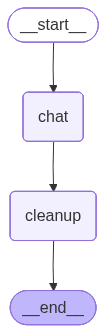

In [20]:
graph

In [21]:
config = {"configurable": {"thread_id": "t1"}}

In [22]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm amir"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='42195eb0-b080-4b74-bdf9-7ffce304ee52'),
  AIMessage(content="LangChain is an open-source framework designed to simplify the development and deployment of large language models (LLMs) like LangGraph. It provides a set of tools and APIs that allow developers to build, train, and deploy LLMs more efficiently, with a focus on flexibility, scalability, and ease of use.\n\n**Key Features of LangChain:**\n\n1. **Modular architecture**: LangChain is designed as a modular framework, allowing developers to easily swap out different components, such as models, trainers, and optimizers, to create customized LLM pipelines.\n2. **Model-agnostic**: LangChain is model-agnostic, meaning it can support a wide range of LLM architectures, including transformer-based models, recurrent neural networks (RNNs), and more.\n3. **Distributed training**: LangChain provides built-in support for distributed train

In [23]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
